In [30]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

In [31]:
test_vids = [
    'churchlandlab_CSHL045_2020-02-27-001',
    'cortexlab_KS020_2020-02-06-001',
    'hoferlab_SWC_043_2020-09-15-001',
    'mrsicflogellab_SWC_052_2020-10-22-001',
    'wittenlab_ibl_witten_27_2021-01-21-001',
]
labels = ['avg', 'still', 'move', 'wheel_turn', 'groom']

In [10]:
# load gt labels
base = '/home/bsb2144/daart_utils/data/ibl/labels-hand/{}_labels.csv'
labels = {}
states = []
for vid in test_vids:
    labs = pd.read_csv(base.format(vid),index_col=0).to_numpy()
    labs = labs.argmax(axis=1)
    states += list(labs)
    labels[vid] = labs
states = np.array(states)

In [18]:
# f1 dict
mod_base = '/home/bsb2144/daart/results_data/ibl/multi-0/dtcn/{}/version_0/{}_states.npy'
f1_meta = {}

In [19]:
def get_results(mod):
    preds = []
    for vid in test_vids:
        p = np.load(mod_base.format(mod, vid))
        p = p.argmax(axis=1)
        preds += list(p)
    preds = np.array(preds)
    return preds

In [45]:
# reg model
mod_reg = 'v2reg'
mods = ['v2reg', 'v1rotate', 'v1shift', 'v1gauss', 'v1shot']

for mod in mods:
    preds = get_results(mod)
    f1 = f1_score(states[states>0], preds[states>0], average=None)
    f1_meta[mod] = [np.mean(f1)] + list(f1)

In [49]:
mods = ['test_allv3']
mod_base = '/home/bsb2144/daart/results_data/ibl/multi-0/dtcn/{}/version_0/{}_states.npy'
for mod in mods:
    preds = get_results(mod)
    f1 = f1_score(states[states>0], preds[states>0], average=None)
    f1_meta[mod] = [np.mean(f1)] + list(f1)

In [50]:
print(f1_meta)

{'v2reg': [0.921243905115959, 0.9495533368365738, 0.8427914110429447, 0.8943206326383897, 0.9983102399459277], 'v1rotate': [0.9248366900347257, 0.9560846560846561, 0.8473019517795637, 0.90104662226451, 0.994913530010173], 'v1shift': [0.9107991848718294, 0.9350582147477361, 0.8188785800726099, 0.8946873530794547, 0.994572591587517], 'v1gauss': [0.9188071896586234, 0.9539925965097832, 0.8234356317257873, 0.9011857707509882, 0.996614759647935], 'v1shot': [0.918105209108927, 0.9465128474043, 0.8356218124754806, 0.8943512172063343, 0.9959349593495934], 'test_allv3': [0.9137516943554655, 0.9547499338449325, 0.8149561236169401, 0.889365760610396, 0.9959349593495934]}


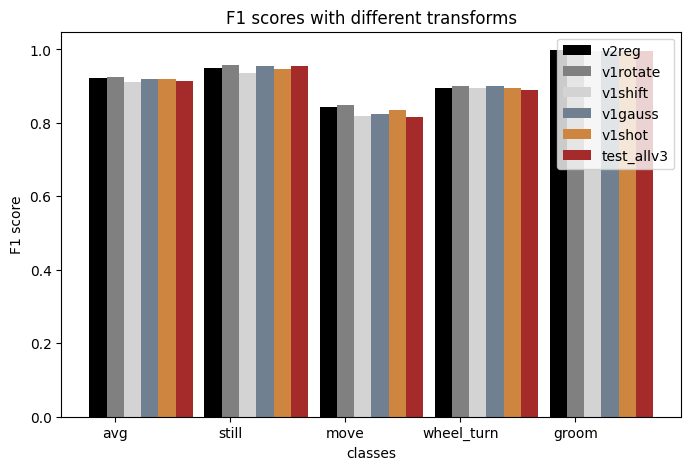

In [52]:
# Numbers of pairs of bars you want
N = len(labels)
# Position of bars on x-axis
ind = np.arange(N)

colors = ['black', 'grey', 'lightgrey', 'slategrey', 'peru', 'brown']
# Figure size
plt.figure(figsize=(8,5))

# Width of a bar 
width = 0.15     
i=0
for mod, bar in f1_meta.items():
    # Plotting
    plt.bar(ind + width*i, bar, width, label=mod, color=colors[i])
    plt.xlabel('classes')
    plt.ylabel('F1 score')
    plt.title('F1 scores with different transforms')

    # xticks()
    # First argument - A list of positions at which ticks should be placed
    # Second argument -  A list of labels to place at the given locations
    plt.xticks(ind + width, labels)
    i+=1
    
# Finding the best position for legends and putting it
plt.legend(loc='best')
plt.show()
